In [1]:
!pip install protobuf==3.20.3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.1/162.1 kB 2.7 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: protobuf
    Found existing installation: protobuf 6.33.0
    Uninstalling protobuf-6.33.0:
      Successfully uninstalled protobuf-6.33.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.12.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
opentelemetry-proto 1.37.0 requires protobuf<7.0,>=5.0, but you have protobuf 3.20.3 which is incompatible.
onnx 1.18.0 requires protobuf>=4.25.1, but you have protobuf 3.20.3 which is incompatible.
a2a-sdk 0.3.10 requires protobuf>=5.29.5, but you have protobuf 3.20.3 which is incompatible.
ray 2.51.1 requires click!=8.3.0,>=7.0, but you have click 8.3.0 which is incompatible.
bigframes 2.12.0 requires rich<14,>=12.4.4, but you have rich 14.2.0 which is incompatible.
tens

*Requirement*

In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
import gc

2025-12-08 00:42:06.315226: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1765154526.558470      47 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765154526.624947      47 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


# Load data
Lấy dữ liệu từ nhánh data, dữ liệu đã được làm sạch và chuẩn hóa nên chỉ thực hiện upload, nếu cần xử lí thêm sẽ bổ sung sau

In [3]:
IMG_SIZE = 150
BATCH_SIZE = 32
EPOCHS = 20
KAGGLE_PATH = '/kaggle/input/processed-img-2/processed/train'
LOCAL_PATH = os.path.join('..', 'data', 'processed', 'train')

if os.path.exists(KAGGLE_PATH):
    print("MÔI TRƯỜNG: KAGGLE GPU")
    dataset_path = KAGGLE_PATH
elif os.path.exists(LOCAL_PATH):
    print("MÔI TRƯỜNG: LOCAL PC")
    dataset_path = LOCAL_PATH
else:
    raise FileNotFoundError("❌ Không tìm thấy dữ liệu! Hãy Add Data trên Kaggle.")

print(f"Đang đọc dữ liệu từ: {dataset_path}")
data = []
labels = []
categories = ['NORMAL', 'PNEUMONIA']

for category in categories:
    path = os.path.join(dataset_path, category)
    class_num = categories.index(category)
    try:
        files = os.listdir(path)
        if 'kaggle' not in dataset_path.lower():
            files = files[:100]
            
        for img_name in files:
            try:
                img_path = os.path.join(path, img_name)
                img_array = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                if img_array is not None:
                    resized_arr = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))
                    data.append(resized_arr)
                    labels.append(class_num)
            except Exception as e:
                pass
    except Exception as e:
        print(f"Lỗi đọc folder {category}: {e}")

print(f"Đã load xong: {len(data)} ảnh.")

MÔI TRƯỜNG: KAGGLE GPU
Đang đọc dữ liệu từ: /kaggle/input/processed-img-2/processed/train
Đã load xong: 17601 ảnh.


In [4]:
X = np.array(data)
y = np.array(labels)

del data
del labels
gc.collect()

X = X / 255.0
X = X.reshape(-1, IMG_SIZE, IMG_SIZE, 1)

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"📊 Train set: {X_train.shape}")
print(f"📊 Val set:   {X_val.shape}")

📊 Train set: (14080, 150, 150, 1)
📊 Val set:   (3521, 150, 150, 1)


# CNN 

Xây dựng mô hình

In [5]:
model = Sequential()

model.add(Input(shape=(IMG_SIZE, IMG_SIZE, 1)))

# Lớp 1
model.add(Conv2D(32, (3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

# Lớp 2
model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

# Lớp 3
model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

# Lớp Phẳng
model.add(Conv2D(256, (3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))
# Lớp Neuron
model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.5)) # Tránh Overfitting
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

I0000 00:00:1765154694.479918      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1765154694.480540      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 18, 18, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 18, 18, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 20736)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    10,617,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,007,617 (41.99 MB)

 Trainable params: 11,006,657 (41.99 MB)

 Non-trainable params: 960 (3.75 KB)

In [6]:
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True, monitor='val_loss'),
    ModelCheckpoint('cnn_pneumonia_model.keras', save_best_only=True, monitor='val_accuracy'),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]

print("Bắt đầu train")
history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    callbacks=callbacks
)

Bắt đầu train
Epoch 1/20


I0000 00:00:1765154704.121723     120 service.cc:148] XLA service 0x7b24c4001840 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1765154704.122790     120 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1765154704.122815     120 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1765154704.667813     120 cuda_dnn.cc:529] Loaded cuDNN version 90300


  3/440 ━━━━━━━━━━━━━━━━━━━━ 18s 43ms/step - accuracy: 0.7066 - loss: 1.6887   

I0000 00:00:1765154710.132023     120 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


440/440 ━━━━━━━━━━━━━━━━━━━━ 28s 39ms/step - accuracy: 0.9032 - loss: 1.2974 - val_accuracy: 0.5856 - val_loss: 71.9601 - learning_rate: 0.0010
Epoch 2/20
440/440 ━━━━━━━━━━━━━━━━━━━━ 15s 34ms/step - accuracy: 0.9650 - loss: 0.1113 - val_accuracy: 0.9753 - val_loss: 0.0640 - learning_rate: 0.0010
Epoch 3/20
440/440 ━━━━━━━━━━━━━━━━━━━━ 15s 34ms/step - accuracy: 0.9715 - loss: 0.0843 - val_accuracy: 0.9824 - val_loss: 0.0495 - learning_rate: 0.0010
Epoch 4/20
440/440 ━━━━━━━━━━━━━━━━━━━━ 15s 33ms/step - accuracy: 0.9784 - loss: 0.0569 - val_accuracy: 0.8890 - val_loss: 0.2887 - learning_rate: 0.0010
Epoch 5/20
440/440 ━━━━━━━━━━━━━━━━━━━━ 15s 34ms/step - accuracy: 0.9815 - loss: 0.0518 - val_accuracy: 0.9571 - val_loss: 0.1524 - learning_rate: 0.0010
Epoch 6/20
439/440 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9825 - loss: 0.0513
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
440/440 ━━━━━━━━━━━━━━━━━━━━ 15s 35ms/step - accuracy: 0.9825 - loss: 0.0513 

In [7]:
from tensorflow.keras.models import load_model
print("🔄 Đang tải model tốt nhất từ file...")
try:
    model_best = load_model('cnn_pneumonia_model.keras')
    print("✅ Đã tạo xong biến 'model_best'!")
except:
    print("⚠️ Không tìm thấy file. Dùng tạm biến 'model' vừa train xong.")
    model_best = model 

🔄 Đang tải model tốt nhất từ file...
✅ Đã tạo xong biến 'model_best'!


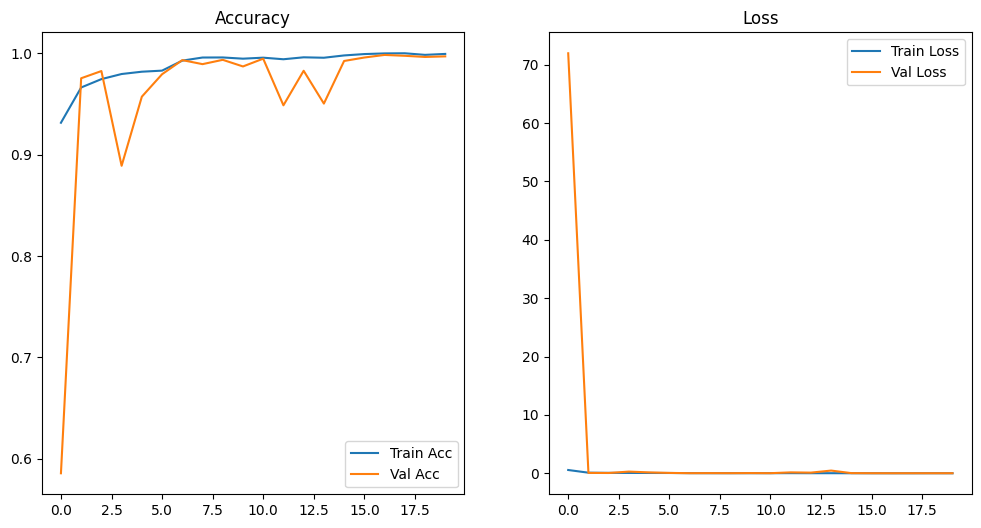

File model đã được lưu: cnn_pneumonia_model.keras


In [8]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Train Acc')
plt.plot(val_acc, label='Val Acc')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(loss, label='Train Loss')
plt.plot(val_loss, label='Val Loss')
plt.title('Loss')
plt.legend()
plt.show()

print("File model đã được lưu: cnn_pneumonia_model.keras")

In [9]:
TEST_PATH = '/kaggle/input/processed-img-2/processed/test'
IMG_SIZE = 150
CATEGORIES = ['NORMAL', 'PNEUMONIA']
X_test_new = []
y_test_new = []

if not os.path.exists(TEST_PATH):
    print("❌ LỖI: Không tìm thấy đường dẫn folder Test!")
else:
    for category in CATEGORIES:
        path = os.path.join(TEST_PATH, category)
        class_num = CATEGORIES.index(category) # 0: NORMAL, 1: PNEUMONIA
        try:
            files = os.listdir(path)
            print(f"   -> Đang đọc folder {category}: {len(files)} ảnh")
            for img_name in files:
                try:
                    img_path = os.path.join(path, img_name)
                    # Đọc ảnh xám
                    img_array = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                    if img_array is not None:
                        # Resize về 150x150
                        resized_arr = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))
                        X_test_new.append(resized_arr)
                        y_test_new.append(class_num)
                except: pass
        except: pass

    X_test_new = np.array(X_test_new).reshape(-1, IMG_SIZE, IMG_SIZE, 1)
    X_test_new = X_test_new / 255.0
    y_test_new = np.array(y_test_new)

    print(f"✅ Đã chuẩn bị xong dữ liệu: {X_test_new.shape}")

   -> Đang đọc folder NORMAL: 231 ảnh
   -> Đang đọc folder PNEUMONIA: 387 ảnh
✅ Đã chuẩn bị xong dữ liệu: (618, 150, 150, 1)


In [10]:
# Cell 3: Load Model từ file
print("🔄 Đang tải model...")

try:
    # Tên file phải khớp với lúc bạn train xong (check cột Output bên phải)
    model_best = load_model('cnn_pneumonia_model.keras')
    print("✅ Đã load thành công model từ file 'cnn_pneumonia_model.keras'")
except:
    print("⚠️ Không tìm thấy file model đã lưu!")
    if 'model' in globals():
        print("-> Đang dùng tạm model vừa train xong trong RAM.")
        model_best = model
    else:
        print("❌ LỖI: Không có model nào để chấm điểm cả.")

🔄 Đang tải model...
✅ Đã load thành công model từ file 'cnn_pneumonia_model.keras'


⏳ Đang chấm bài (Predicting)...
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step

🏆 KẾT QUẢ CUỐI CÙNG (TEST ACCURACY): 82.69%
Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.98      0.55      0.70       231
   PNEUMONIA       0.79      0.99      0.88       387

    accuracy                           0.83       618
   macro avg       0.88      0.77      0.79       618
weighted avg       0.86      0.83      0.81       618



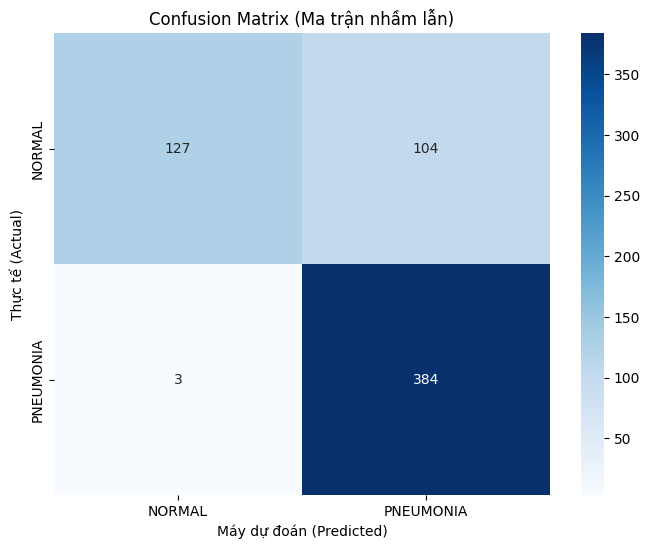

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from tensorflow.keras.models import load_model

if 'model_best' not in globals():
    print("🔄 Đang tải lại model tốt nhất từ file...")
    try:
        # Nhớ kiểm tra tên file .keras của bạn có đúng là tên này không nhé
        model_best = load_model('cnn_pneumonia_model.keras') 
        print("✅ Đã load xong model_best!")
    except:
        print("⚠️ Không tìm thấy file model. Đang dùng tạm biến 'model' hiện tại.")
        if 'model' in globals():
            model_best = model
        else:
            raise ValueError("❌ Lỗi: Không tìm thấy model nào cả! Bạn cần train hoặc upload file model trước.")

print("⏳ Đang chấm bài (Predicting)...")

try:
    predictions = model_best.predict(X_test_new)
except NameError:
    print("❌ Lỗi: Biến 'X_test_new' chưa được tạo. Bạn hãy chạy lại Cell load dữ liệu Test ở trên trước nhé!")
    raise
y_pred = (predictions >= 0.5).astype(int)

try:
    acc = accuracy_score(y_test_new, y_pred)
    
    print("\n" + "="*40)
    print(f"🏆 KẾT QUẢ CUỐI CÙNG (TEST ACCURACY): {acc*100:.2f}%")
    print("="*40)

    # Báo cáo chi tiết
    print("Classification Report:")
    print(classification_report(y_test_new, y_pred, target_names=['NORMAL', 'PNEUMONIA']))
    cm = confusion_matrix(y_test_new, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['NORMAL', 'PNEUMONIA'], 
                yticklabels=['NORMAL', 'PNEUMONIA'])
    plt.xlabel('Máy dự đoán (Predicted)')
    plt.ylabel('Thực tế (Actual)')
    plt.title('Confusion Matrix (Ma trận nhầm lẫn)')
    plt.show()

except NameError:
    print("❌ Lỗi: Biến 'y_test_new' chưa có. Hãy chạy lại Cell load dữ liệu Test.")

Đang xem xét ảnh: person78_bacteria_387.jpeg


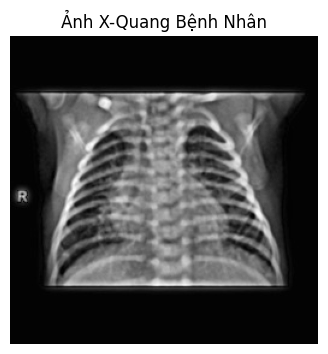

------------------------------
KẾT QUẢ CHẨN ĐOÁN CỦA CNN:
KẾT LUẬN: VIÊM PHỔI (PNEUMONIA)
Độ tin cậy: 100.00%
------------------------------


In [19]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

def predicted_after_train(image_path):
    print(f"Đang xem xét ảnh: {os.path.basename(image_path)}")
    try:
        img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            print("Lỗi: Không đọc được ảnh. Kiểm tra lại đường dẫn!")
            return
        
        plt.figure(figsize=(4, 4))
        plt.imshow(img, cmap='gray')
        plt.title("Ảnh X-Quang Bệnh Nhân")
        plt.axis('off')
        plt.show()

        img_resized = cv2.resize(img, (150, 150)) 
        img_input = np.array(img_resized) / 255.0 
        img_input = img_input.reshape(1, 150, 150, 1) 

        global model_best
        if 'model_best' not in globals():
            model_best = load_model('cnn_pneumonia_model.keras')

        prediction = model_best.predict(img_input, verbose=0)
        score = prediction[0][0] # Giá trị từ 0.0 đến 1.0

        # B5: Phán bệnh
        print("-" * 30)
        print("KẾT QUẢ CHẨN ĐOÁN CỦA CNN:")
        
        if score >= 0.5:
            do_tin_cay = score * 100
            print(f"KẾT LUẬN: VIÊM PHỔI (PNEUMONIA)")
            print(f"Độ tin cậy: {do_tin_cay:.2f}%")
        else:
            do_tin_cay = (1 - score) * 100
            print(f"KẾT LUẬN: BÌNH THƯỜNG (NORMAL)")
            print(f"Độ tin cậy: {do_tin_cay:.2f}%")
        print("-" * 30)

    except Exception as e:
        print(f"Có lỗi xảy ra: {e}")

TEST_PATH = '/kaggle/input/processed-img-2/processed/test'
# TEST_DIR = os.path.join('..', 'data', 'processed', 'test') # Local
# (Code dưới tự lấy lại biến test_path từ cell trước cho tiện)

if 'TEST_PATH' in globals() and os.path.exists(TEST_PATH):
    import random

    folder_benh = os.path.join(TEST_PATH, 'PNEUMONIA')
    ds_anh_benh = os.listdir(folder_benh)
    anh_ngau_nhien = random.choice(ds_anh_benh)
    path_anh = os.path.join(folder_benh, anh_ngau_nhien)
    
    predicted_after_train(path_anh)
    
else:
    print("Chưa xác định được folder Test. Bạn hãy nhập đường dẫn ảnh cụ thể vào hàm nhé!")